## Loading the data and other imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
import pickle
import joblib
from scipy.stats import chi2_contingency

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [4]:
df = pd.read_csv('data_set/hypertension_dataset.csv')

## Exploratory Data Analysis

In [5]:
df.shape

(1985, 11)

In [6]:
df.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [7]:
df.tail()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
1980,56,10.2,0,Normal,6.5,25.0,Diuretic,Yes,Low,Non-Smoker,Yes
1981,29,8.9,4,Hypertension,6.9,16.9,NaN,Yes,High,Non-Smoker,Yes
1982,64,5.9,9,Normal,5.6,18.9,ACE Inhibitor,Yes,Moderate,Non-Smoker,Yes
1983,35,7.4,8,Prehypertension,8.2,29.2,NaN,Yes,Moderate,Non-Smoker,No
1984,38,7.3,0,Normal,8.3,18.6,NaN,Yes,Low,Smoker,No


In [8]:
df.columns

Index(['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension'],
      dtype='str')

In [9]:
cl = ['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension']

In [10]:
for i in cl:
    print(f'{i}: {df[i].unique()}')

Age: [69 32 78 38 41 20 39 70 19 47 55 81 77 50 75 66 76 59 79 64 68 72 24 56
 35 21 31 26 61 25 52 53 67 23 71 80 51 65 57 43 58 46 62 82 18 28 22 45
 29 40 54 44 60 30 49 83 74 73 36 34 33 37 84 48 42 63 27]
Salt_Intake: [ 8.  11.7  9.5 10.   9.8 10.8  8.9  5.9  9.3  7.2  7.4  9.7 11.   8.5
  9.1 11.9  9.  13.7  9.6  5.  11.1  8.2  6.1  8.1  6.8  7.3 11.8  9.4
 10.9  6.9  8.3  6.7  7.6  9.9  7.8 12.   7.7 10.4  5.7  5.4 13.6 11.6
 12.5 12.6 10.5 10.1  8.7 11.5  6.2  7.1  4.8  6.5 12.2  6.6 10.7 12.3
  7.5  6.3  8.8  5.3  2.8  8.4  9.2 10.3  7.   3.7  7.9  8.6  6.   5.8
  6.4  2.7  3.8 11.2 14.9  5.6 10.2 10.6 11.3  4.3 12.4  4.2  3.1 12.8
  5.5  4.7  4.9 12.1  5.2  5.1 13.   4.5  3.4 13.8 14.8  2.6  2.5 14.
  3.6  3.9 11.4 13.3 12.7  4.1  4.6  3.3 14.7 13.2 14.4 14.5 13.4  3.2
  4.  13.9 12.9  3.  16.4  3.5  4.4 13.1 14.2]
Stress_Score: [ 9 10  3  1  0  7  5  8  6  4  2]
BP_History: <StringArray>
['Normal', 'Hypertension', 'Prehypertension']
Length: 3, dtype: str
Sleep_Duration: [ 6.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   str    
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   str    
 7   Family_History    1985 non-null   str    
 8   Exercise_Level    1985 non-null   str    
 9   Smoking_Status    1985 non-null   str    
 10  Has_Hypertension  1985 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 170.7 KB


In [12]:
df.describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

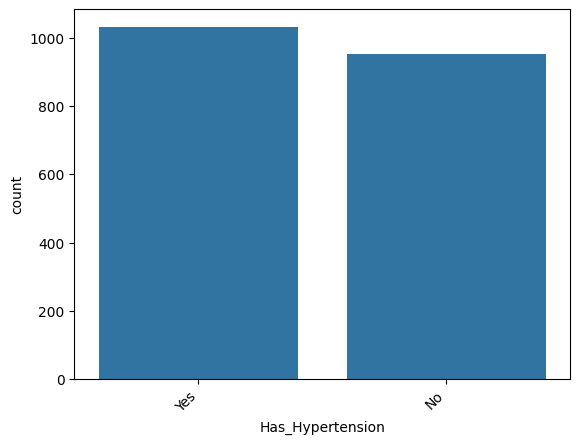

In [13]:
sns.countplot(x='Has_Hypertension',data=df)
plt.xticks(rotation=45, ha='right')

In [14]:
df.columns

Index(['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension'],
      dtype='str')

([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

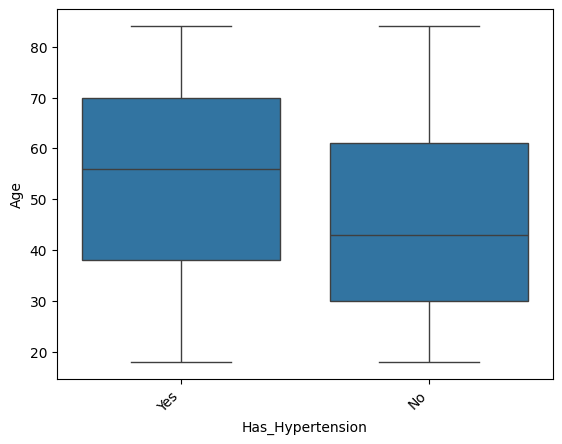

In [15]:
sns.boxplot(x='Has_Hypertension',y='Age',data=df)
plt.xticks(rotation=45, ha='right')

([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

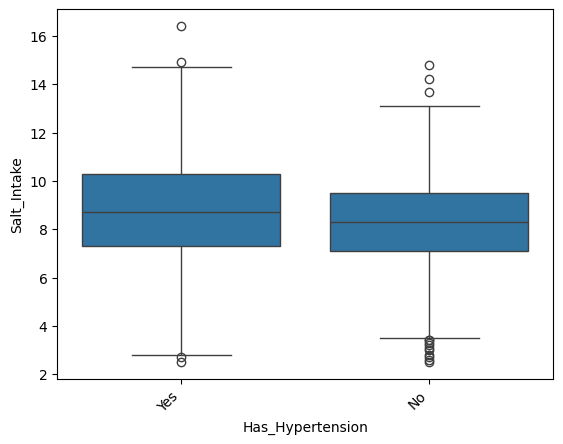

In [16]:
sns.boxplot(x='Has_Hypertension',y='Salt_Intake',data=df)
plt.xticks(rotation=45, ha='right')

([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

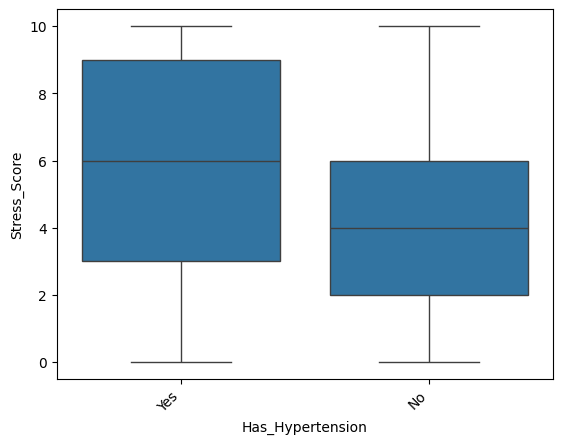

In [17]:
sns.boxplot(x='Has_Hypertension',y='Stress_Score',data=df)
plt.xticks(rotation=45, ha='right')

([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

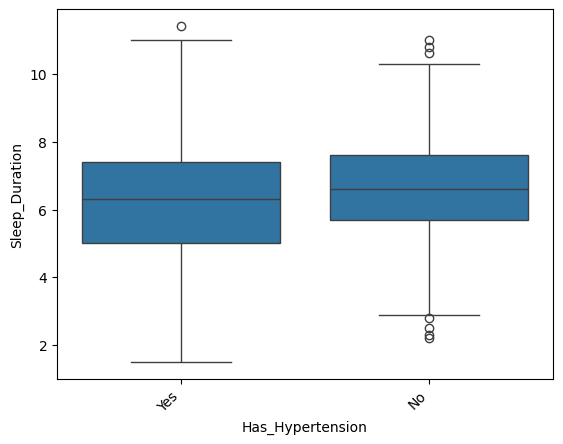

In [18]:
sns.boxplot(x='Has_Hypertension',y='Sleep_Duration',data=df)
plt.xticks(rotation=45, ha='right')

([0, 1], [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

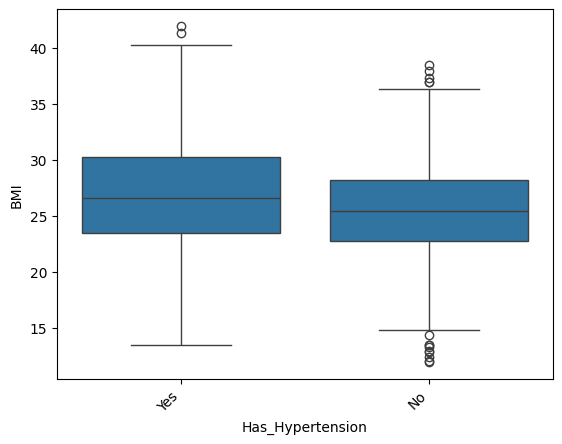

In [19]:
sns.boxplot(x='Has_Hypertension',y='BMI',data=df)
plt.xticks(rotation=45, ha='right')

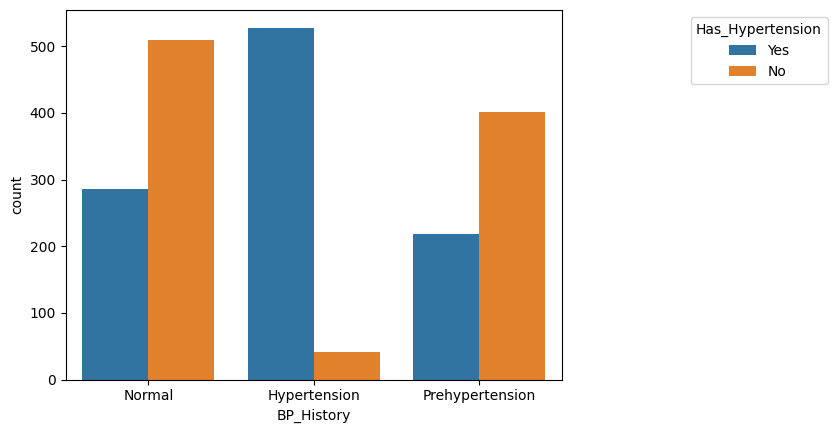

In [20]:
sns.countplot(x='BP_History',data=df,hue='Has_Hypertension')
plt.legend(title='Has_Hypertension', loc='upper right', bbox_to_anchor=(1.55, 1.), ncol=1)

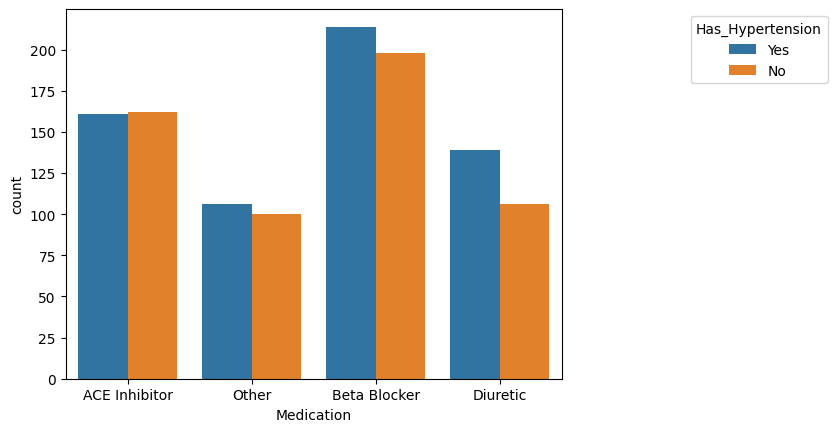

In [21]:
sns.countplot(x='Medication',data=df,hue='Has_Hypertension')
plt.legend(title='Has_Hypertension', loc='upper right', bbox_to_anchor=(1.55, 1.), ncol=1)

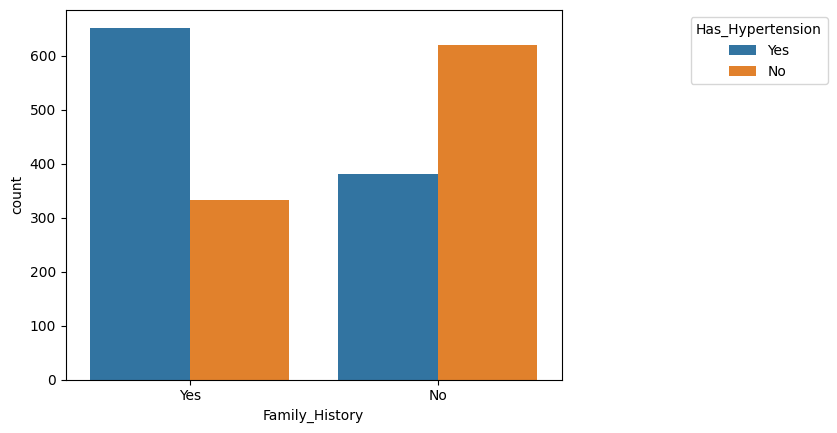

In [22]:
sns.countplot(x='Family_History',data=df,hue='Has_Hypertension')
plt.legend(title='Has_Hypertension', loc='upper right', bbox_to_anchor=(1.55, 1.), ncol=1)

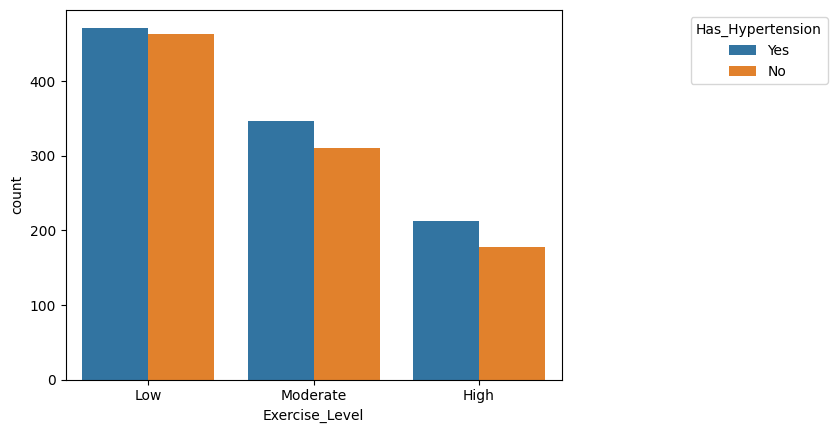

In [23]:
sns.countplot(x='Exercise_Level',data=df,hue='Has_Hypertension')
plt.legend(title='Has_Hypertension', loc='upper right', bbox_to_anchor=(1.55, 1.), ncol=1)

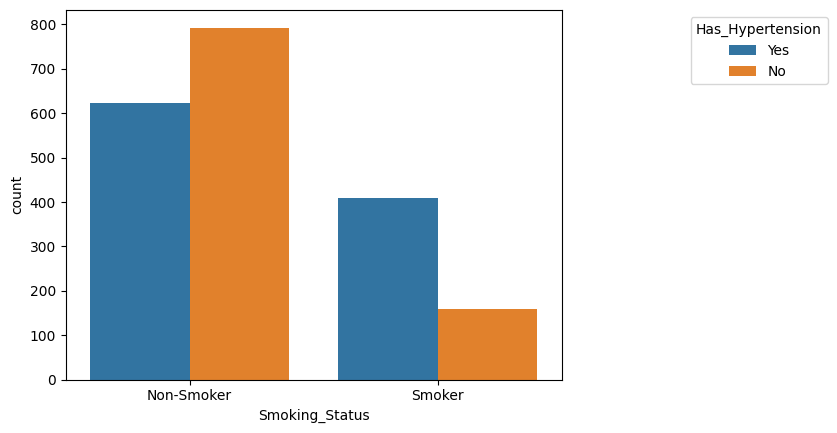

In [24]:
sns.countplot(x='Smoking_Status',data=df,hue='Has_Hypertension')
plt.legend(title='Has_Hypertension', loc='upper right', bbox_to_anchor=(1.55, 1.), ncol=1)

### analyze the association between each independent variable and the Category

#### categorical features and Category

In [25]:
categorical_features =list(df.select_dtypes(['object']).columns)[:-1]
categorical_features

['BP_History',
 'Medication',
 'Family_History',
 'Exercise_Level',
 'Smoking_Status']

In [26]:
def cramers_v_and_p(matrix):
    chi2, p, _, _ = chi2_contingency(matrix)
    n = matrix.sum().sum()
    r, k = matrix.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return cramers_v, p

In [27]:
results = []

for features in categorical_features:

    matrix = pd.crosstab(df[features], df['Has_Hypertension'])
    
    cv, p_value = cramers_v_and_p(matrix)
    results.append((features, cv, p_value))

In [28]:
results_df = pd.DataFrame(results, columns=['categorical features', 'Cramér\'s V', 'p-value'])

In [29]:
results_df['Significant'] = results_df['p-value'] < 0.05

In [30]:
results_df

,categorical features,Cramér's V,p-value,Significant
0,BP_History,0.517774,2.776075e-116,True
1,Medication,0.048513,4.249486e-01,False
2,Family_History,0.281136,5.411556e-36,True
3,Exercise_Level,0.031980,3.623828e-01,False
4,Smoking_Status,0.250321,6.951639e-29,True


removing unnecessary columns

In [31]:
df.drop(['Medication', "Exercise_Level"], axis=1, inplace=True)

In [32]:
categorical_features =list(df.select_dtypes(['object']).columns)[:-1]
categorical_features

['BP_History', 'Family_History', 'Smoking_Status']

#### Numerical features and Category

In [33]:
le = LabelEncoder()
df['Category Encoded'] = le.fit_transform(df['Has_Hypertension'])

In [34]:
corr_for_numerical = df.drop(categorical_features + ["Has_Hypertension"], axis=1).corr()
corr_for_numerical

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI,Category Encoded
Age,1.000000,0.011205,-0.032184,-0.011839,-0.023498,0.210677
Salt_Intake,0.011205,1.000000,0.008129,0.020394,0.039530,0.114415
Stress_Score,-0.032184,0.008129,1.000000,0.021191,0.011450,0.186910
Sleep_Duration,-0.011839,0.020394,0.021191,1.000000,0.025476,-0.119561
BMI,-0.023498,0.039530,0.011450,0.025476,1.000000,0.145093
Category Encoded,0.210677,0.114415,0.186910,-0.119561,0.145093,1.000000


In [35]:
corr_for_numerical["Category Encoded"]

Age                 0.210677
Salt_Intake         0.114415
Stress_Score        0.186910
Sleep_Duration     -0.119561
BMI                 0.145093
Category Encoded    1.000000
Name: Category Encoded, dtype: float64

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Age'),
  Text(1, 0, 'Salt_Intake'),
  Text(2, 0, 'Stress_Score'),
  Text(3, 0, 'Sleep_Duration'),
  Text(4, 0, 'BMI'),
  Text(5, 0, 'Category Encoded')])

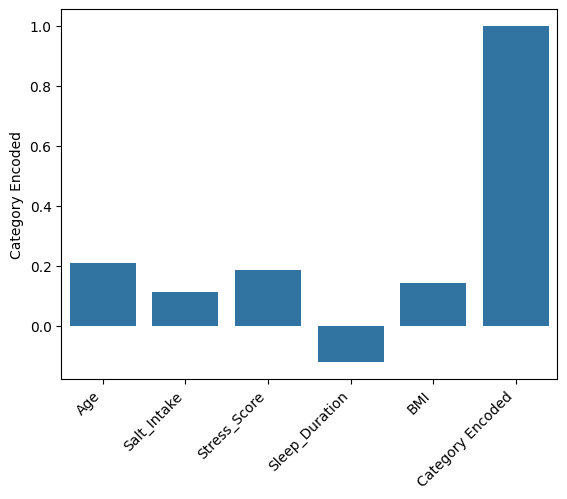

In [36]:
sns.barplot( data=corr_for_numerical["Category Encoded"] )
plt.xticks(rotation=45, ha='right')

In [37]:
df.drop("Category Encoded", axis=1, inplace=True)

In [38]:
df.drop("Stress_Score", axis=1, inplace=True)

In [39]:
df.columns

Index(['Age', 'Salt_Intake', 'BP_History', 'Sleep_Duration', 'BMI',
       'Family_History', 'Smoking_Status', 'Has_Hypertension'],
      dtype='str')

## Data PreProcessing

In [40]:
df.head()

,Age,Salt_Intake,BP_History,Sleep_Duration,BMI,Family_History,Smoking_Status,Has_Hypertension
0,69,8.0,Normal,6.4,25.8,Yes,Non-Smoker,Yes
1,32,11.7,Normal,5.4,23.4,No,Non-Smoker,No
2,78,9.5,Normal,7.1,18.7,No,Non-Smoker,No
3,38,10.0,Hypertension,4.2,22.1,No,Non-Smoker,Yes
4,41,9.8,Prehypertension,5.8,16.2,No,Non-Smoker,No


In [41]:
df.isnull().sum()

Age                 0
Salt_Intake         0
BP_History          0
Sleep_Duration      0
BMI                 0
Family_History      0
Smoking_Status      0
Has_Hypertension    0
dtype: int64

#### split dataset into training and testing sets

In [42]:
X = df.drop("Has_Hypertension", axis=1)
y = df["Has_Hypertension"]

#### Categorical Variables Handling

In [43]:
cat_features = list(X.select_dtypes(['object']).columns)
cat_features

['BP_History', 'Family_History', 'Smoking_Status']

In [44]:
preprocessor = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(handle_unknown='ignore'), cat_features)],
    remainder='passthrough')

In [45]:
X = preprocessor.fit_transform(X)

In [46]:
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

#### Train Test Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Models Training 

In [48]:
df["Has_Hypertension"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [49]:
classes = ['Yes', 'No']

def plot_confusion_matrix(y_true, y_pred, classes, figsize=(6, 4), cmap=plt.cm.Blues):

    cm = confusion_matrix(y_true, y_pred) 
    
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, cmap=cmap, fmt=".2f", xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Confusion Matrix')
    plt.show()

### SVM

In [50]:
svm_classifier = SVC(kernel='linear')

In [51]:
svm_classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [52]:
y_pred = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("SVM_Accuracy:", accuracy*100)

print(classification_report(y_test, y_pred))

SVM_Accuracy: 84.73154362416108
              precision    recall  f1-score   support

          No       0.83      0.86      0.84       287
         Yes       0.87      0.83      0.85       309

    accuracy                           0.85       596
   macro avg       0.85      0.85      0.85       596
weighted avg       0.85      0.85      0.85       596



In [53]:
y_pred = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("SVM_Accuracy:", accuracy*100)

print(classification_report(y_test, y_pred))

SVM_Accuracy: 84.73154362416108
              precision    recall  f1-score   support

          No       0.83      0.86      0.84       287
         Yes       0.87      0.83      0.85       309

    accuracy                           0.85       596
   macro avg       0.85      0.85      0.85       596
weighted avg       0.85      0.85      0.85       596



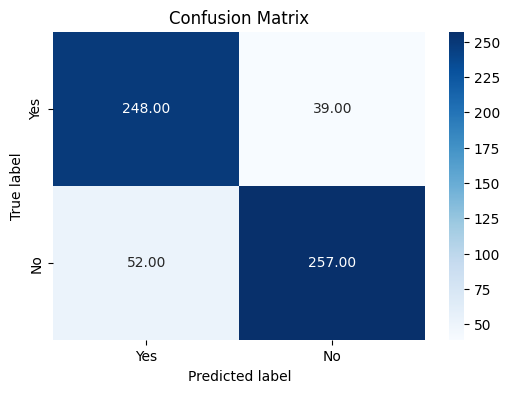

In [54]:
plot_confusion_matrix(y_test, y_pred, classes)

### KNN

In [55]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)

In [56]:
knn_classifier.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [57]:
y_pred_knn = knn_classifier.predict(X_test)

In [58]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn*100)


print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 65.77181208053692
              precision    recall  f1-score   support

          No       0.63      0.71      0.67       287
         Yes       0.69      0.61      0.65       309

    accuracy                           0.66       596
   macro avg       0.66      0.66      0.66       596
weighted avg       0.66      0.66      0.66       596



In [59]:
confusion_matrix(y_test,y_pred_knn)

array([[203,  84],
       [120, 189]])

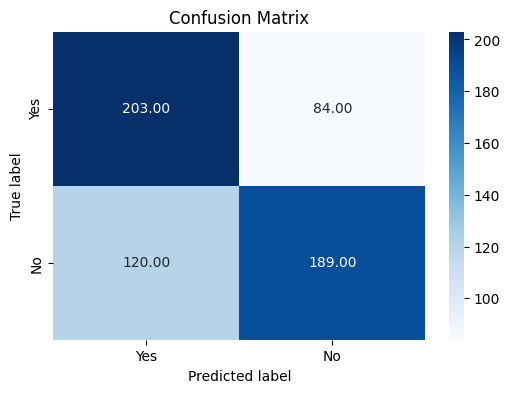

In [60]:
plot_confusion_matrix(y_test, y_pred_knn, classes)

## MLPClassifier

In [61]:
mlp_classifier = MLPClassifier()

In [62]:
mlp_classifier.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [63]:
y_pred_mlp = mlp_classifier.predict(X_test)

In [64]:
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print("MLPClassifier Accuracy:", accuracy_mlp*100)

print(classification_report(y_test, y_pred_mlp))

MLPClassifier Accuracy: 85.06711409395973
              precision    recall  f1-score   support

          No       0.85      0.83      0.84       287
         Yes       0.85      0.87      0.86       309

    accuracy                           0.85       596
   macro avg       0.85      0.85      0.85       596
weighted avg       0.85      0.85      0.85       596



In [65]:
confusion_matrix(y_test,y_pred_mlp)

array([[239,  48],
       [ 41, 268]])

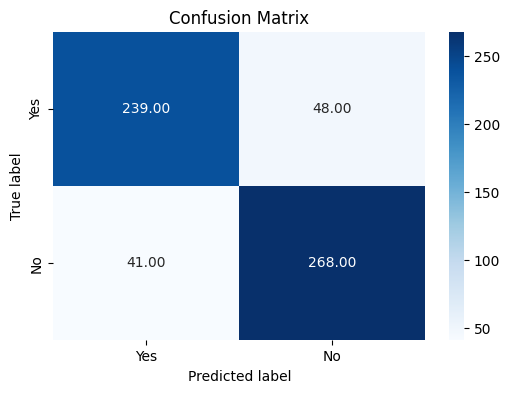

In [66]:
plot_confusion_matrix(y_test, y_pred_mlp, classes)

## Random Forest Classifier

In [67]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

In [68]:
rf_classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [69]:
y_pred_rf = rf_classifier.predict(X_test)

In [70]:
accuracy_mlp = accuracy_score(y_test, y_pred_rf)
print("RF_Classifier Accuracy:", accuracy_mlp*100)

print(classification_report(y_test, y_pred_rf))

RF_Classifier Accuracy: 87.58389261744966
              precision    recall  f1-score   support

          No       0.85      0.90      0.88       287
         Yes       0.90      0.85      0.88       309

    accuracy                           0.88       596
   macro avg       0.88      0.88      0.88       596
weighted avg       0.88      0.88      0.88       596



In [71]:
confusion_matrix(y_test,y_pred_rf)

array([[259,  28],
       [ 46, 263]])

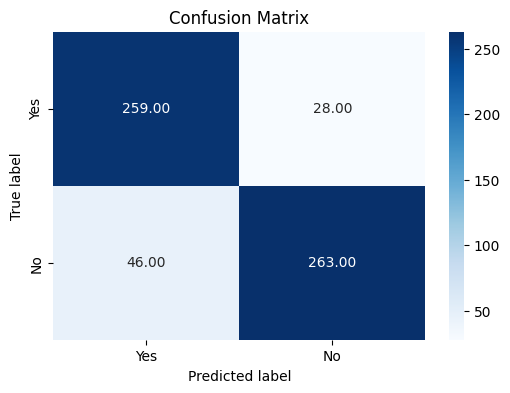

In [72]:
plot_confusion_matrix(y_test, y_pred_rf, classes)

## Save Best Model

In [73]:
with open('RF_model.pkl', 'wb') as file:
    pickle.dump(rf_classifier, file)

## check predictions

In [74]:
with open('RF_model_hypertension.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [75]:
loaded_preprocessor = joblib.load('preprocessor_hypertension.pkl')

In [76]:
for i in cat_features:
    print(f'{i}: {df[i].unique()}')

BP_History: <StringArray>
['Normal', 'Hypertension', 'Prehypertension']
Length: 3, dtype: str
Family_History: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Smoking_Status: <StringArray>
['Non-Smoker', 'Smoker']
Length: 2, dtype: str


In [77]:
def get_prediction(df):
    x =loaded_preprocessor.transform(df) 
    y_pred = loaded_model.predict(x)
    # print(y_pred[0])
    return y_pred[0]

In [78]:
df.head(5)

,Age,Salt_Intake,BP_History,Sleep_Duration,BMI,Family_History,Smoking_Status,Has_Hypertension
0,69,8.0,Normal,6.4,25.8,Yes,Non-Smoker,Yes
1,32,11.7,Normal,5.4,23.4,No,Non-Smoker,No
2,78,9.5,Normal,7.1,18.7,No,Non-Smoker,No
3,38,10.0,Hypertension,4.2,22.1,No,Non-Smoker,Yes
4,41,9.8,Prehypertension,5.8,16.2,No,Non-Smoker,No


In [79]:
dict_sample1 = {
    'Age': 69,
    'Salt_Intake': 8,
    'BP_History': 'Normal',
    'Sleep_Duration': 6.4,
    'BMI': 25.8,
    'Family_History': 'Yes',
    'Smoking_Status': 'Non-Smoker'
}
sample1 = pd.DataFrame([dict_sample1])
get_prediction(sample1)

'Yes'

In [80]:
dict_sample2 = {
    'Age': 32,
    'Salt_Intake': 11.7,
    'BP_History': 'Normal',
    'Sleep_Duration': 5.4,
    'BMI': 23.8,
    'Family_History': 'No',
    'Smoking_Status': 'Non-Smoker'
}
sample2 = pd.DataFrame([dict_sample2])
get_prediction(sample2)

'No'

In [81]:
from hypertension import get_prediction

In [82]:
sample2 = pd.DataFrame([dict_sample2])

In [83]:
sample2

,Age,Salt_Intake,BP_History,Sleep_Duration,BMI,Family_History,Smoking_Status
0,32,11.7,Normal,5.4,23.8,No,Non-Smoker


In [85]:
sample2 = sample2.reset_index(drop=True)

In [87]:
sample2

,Age,Salt_Intake,BP_History,Sleep_Duration,BMI,Family_History,Smoking_Status
0,32,11.7,Normal,5.4,23.8,No,Non-Smoker


In [86]:
print(get_prediction(sample2))

KeyError: 'age'